In [1]:
!pip install langchain-text-splitters chromadb langchain-chroma langchain-openai matplotlib scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.1/20.1 MB 21.0 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 20.5 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 23.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 19.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.3/17.3 MB 20.6 MB/s  0:00:00m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 20.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 625.2/625.2 kB 20.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 27.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 21.5 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 536.2/536.2 kB 13.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24/24 [langchain-chroma][chromadb]ce-hub]


In [2]:
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_chroma import Chroma # this is vector db 
from langchain_openai import OpenAIEmbeddings
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.decomposition import PCA
import numpy as np


In [3]:
print("loading the pdf.....")
loader = PyPDFLoader("AI_TrainingPLan.pdf")
docs = loader.load()
# till here we are only reading the document and creating document objects

loading the pdf.....


In [6]:
print(f"  Pages loaded     : {len(docs)}")
print(f"  First page meta  : {docs[0].metadata}")
print(f"  Sample content   : {docs[0].page_content[:200]}...") # extract 1st 200 characters only

  Pages loaded     : 8
  First page meta  : {'producer': 'pdfTeX-1.40.26', 'creator': 'LaTeX with hyperref', 'creationdate': '2025-04-04T15:38:00+00:00', 'author': '', 'keywords': '', 'moddate': '2025-04-04T15:38:00+00:00', 'ptex.fullbanner': 'This is pdfTeX, Version 3.141592653-2.6-1.40.26 (TeX Live 2024) kpathsea version 6.4.0', 'subject': '', 'title': 'Comprehensive Generative AI Learning Path', 'trapped': '/False', 'source': 'AI_TrainingPLan.pdf', 'total_pages': 8, 'page': 0, 'page_label': '1'}
  Sample content   : Comprehensive Generative AI Learning Path
Curated by Anish Roychowdhury
April 4, 2025
Contents
1 F oundations of Generative AI 3
1.1 Introduction to Generative AI . . . . . . . . . . . . . . . . . . ....


In [8]:
print("----Chunking Documents------")

text_splitter = RecursiveCharacterTextSplitter(chunk_size=100, chunk_overlap = 40)

chunks = text_splitter.split_documents(docs)

print("Total chunks created...", {len(chunks)})
print("Sample of page content: ", {chunks[0].page_content[:300]})

print("Printing Sample chunks")

print(chunks[0])
print("===================")
print(chunks[1])
print("===================")
print(chunks[2])
print("===================")

----Chunking Documents------
Total chunks created... {206}
Sample of page content:  {'Comprehensive Generative AI Learning Path\nCurated by Anish Roychowdhury\nApril 4, 2025\nContents'}
Printing Sample chunks
page_content='Comprehensive Generative AI Learning Path
Curated by Anish Roychowdhury
April 4, 2025
Contents' metadata={'producer': 'pdfTeX-1.40.26', 'creator': 'LaTeX with hyperref', 'creationdate': '2025-04-04T15:38:00+00:00', 'author': '', 'keywords': '', 'moddate': '2025-04-04T15:38:00+00:00', 'ptex.fullbanner': 'This is pdfTeX, Version 3.141592653-2.6-1.40.26 (TeX Live 2024) kpathsea version 6.4.0', 'subject': '', 'title': 'Comprehensive Generative AI Learning Path', 'trapped': '/False', 'source': 'AI_TrainingPLan.pdf', 'total_pages': 8, 'page': 0, 'page_label': '1'}
page_content='April 4, 2025
Contents
1 F oundations of Generative AI 3' metadata={'producer': 'pdfTeX-1.40.26', 'creator': 'LaTeX with hyperref', 'creationdate': '2025-04-04T15:38:00+00:00', 'author': '', 'keywor

In [ ]:
print("-------Embedding Model----------")

embedding_model = OpenAIEmbeddings(model ="text-embedding-3-large")

print(f"Embedding {len(chunks)} ....")

vectorstore = Chroma.from_documents(
    documents = chunks,
    embedding=embedding_model,
    persist_directory="./chroma_db",
    collection_name = "ai_training_plan"
)

print("Total chunks stored in vectorstore.....\n")
total_stored = vectorstore._collection.count()
print(f"total vectors stored in Chroma DB : {total_stored}")

# 206 chunks are created by the text splitter

-------Embedding Model----------
Embedding 206 ....
Total chunks stored in vectorstore.....

total vectors stored in Chroma DB : 206


In [12]:
# fetch everything from chroma collection
collection_data = vectorstore._collection.get(include=["embeddings", "documents", "metadatas"])

ids        = collection_data["ids"]
embeddings = collection_data["embeddings"]
documents  = collection_data["documents"]
metadatas  = collection_data["metadatas"]

print(f"  Total IDs retrieved : {len(ids)}\n")

  Total IDs retrieved : 206



In [16]:

# show first 5 in detail
for i in range(min(5, len(ids))):
    print(f"  ── Chunk {i} ──────────────────────────────────")
    print(f"  ID         : {ids[i]}")
    print(f"  Metadata   : {metadatas[i]}")
    print(f"  Content    : {documents[i][:120]}...")
    print(f"  Vector     : [{embeddings[i][0]:.6f}, {embeddings[i][1]:.6f}, "
          f"{embeddings[i][2]:.6f}, ... ] ")
    print()

  ── Chunk 0 ──────────────────────────────────
  ID         : 07fa654b-03f1-419b-9929-4065263a1015
  Metadata   : {'page': 0, 'ptex.fullbanner': 'This is pdfTeX, Version 3.141592653-2.6-1.40.26 (TeX Live 2024) kpathsea version 6.4.0', 'moddate': '2025-04-04T15:38:00+00:00', 'producer': 'pdfTeX-1.40.26', 'author': '', 'total_pages': 8, 'page_label': '1', 'title': 'Comprehensive Generative AI Learning Path', 'source': 'AI_TrainingPLan.pdf', 'subject': '', 'creationdate': '2025-04-04T15:38:00+00:00', 'keywords': '', 'creator': 'LaTeX with hyperref', 'trapped': '/False'}
  Content    : Comprehensive Generative AI Learning Path
Curated by Anish Roychowdhury
April 4, 2025
Contents...
  Vector     : [-0.015898, -0.005453, -0.014420, ... ] 

  ── Chunk 1 ──────────────────────────────────
  ID         : 0059c543-ac40-4a69-8779-fa668cfbd3c4
  Metadata   : {'creationdate': '2025-04-04T15:38:00+00:00', 'subject': '', 'keywords': '', 'total_pages': 8, 'source': 'AI_TrainingPLan.pdf', 'author': ''

In [17]:
# ── 6. RETRIEVER ─────────────────────────────────────────────────────────────
print("\n" + "="*60)
print("STEP 6 : QUERYING THE VECTORSTORE")
print("="*60)

retriever = vectorstore.as_retriever(search_kwargs={"k": 3})
query = "What is the AI training plan?"
print(f"  Query : '{query}'")
print(f"  What happens : query → embed → cosine similarity → top 5 chunks\n")

relevant_chunks = retriever.invoke(query)

for i, chunk in enumerate(relevant_chunks):
    print(f"  ── Retrieved Chunk {i+1} ──")
    print(f"  page_content : {chunk.page_content[:200]}")
    print(f"  metadata     : {chunk.metadata}")
    print()


STEP 6 : QUERYING THE VECTORSTORE
  Query : 'What is the AI training plan?'
  What happens : query → embed → cosine similarity → top 5 chunks

  ── Retrieved Chunk 1 ──
  page_content : 13.2 AI Research Frontiers . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . .
  metadata     : {'keywords': '', 'subject': '', 'ptex.fullbanner': 'This is pdfTeX, Version 3.141592653-2.6-1.40.26 (TeX Live 2024) kpathsea version 6.4.0', 'producer': 'pdfTeX-1.40.26', 'page': 1, 'page_label': '2', 'creationdate': '2025-04-04T15:38:00+00:00', 'creator': 'LaTeX with hyperref', 'total_pages': 8, 'moddate': '2025-04-04T15:38:00+00:00', 'trapped': '/False', 'author': '', 'title': 'Comprehensive Generative AI Learning Path', 'source': 'AI_TrainingPLan.pdf'}

  ── Retrieved Chunk 2 ──
  page_content : Comprehensive Generative AI Learning Path
Curated by Anish Roychowdhury
April 4, 2025
Contents
  metadata     : {'trapped': '/False', 'source': 'AI_TrainingPLan.pdf', 'keywords': '', 'creator':


STEP 7 : VISUALIZING VECTORS (PCA → 2D)
  PCA reduces them to 2D while preserving relative distances

  Original shape  : (206, 3072)
  Reduced shape   : (206, 2)
  Variance kept   : 18.65%


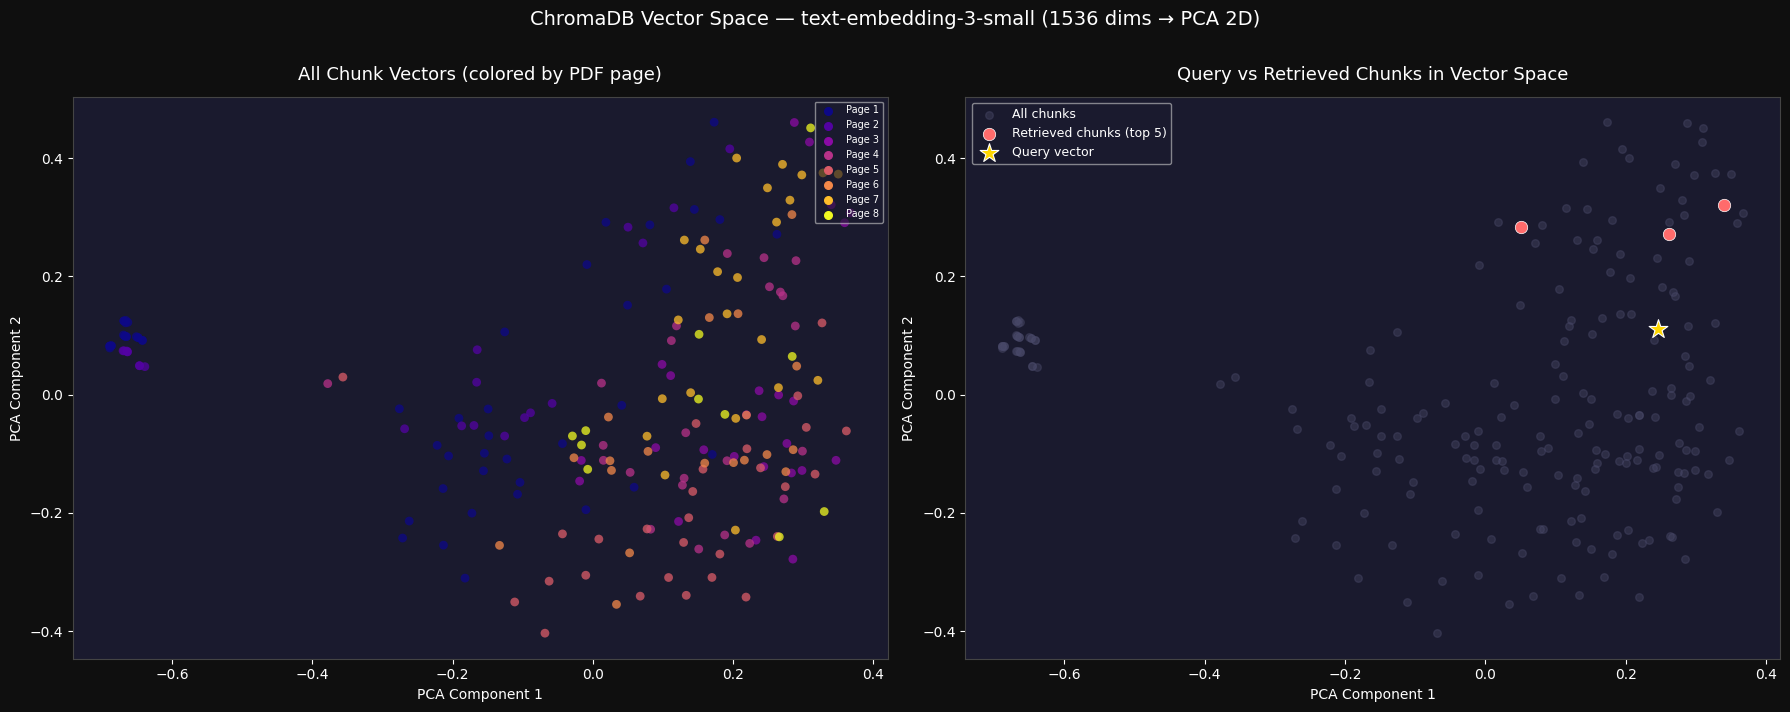


  Plot saved → vector_visualization.png


In [18]:
# ── 7. VISUALIZE VECTORS ─────────────────────────────────────────────────────
print("\n" + "="*60)
print("STEP 7 : VISUALIZING VECTORS (PCA → 2D)")
print("="*60)

print("  PCA reduces them to 2D while preserving relative distances\n")

vectors_np = np.array(embeddings)
pages      = [m.get("page", 0) for m in metadatas]
unique_pages = sorted(set(pages))

# PCA reduction
pca        = PCA(n_components=2, random_state=42)
vectors_2d = pca.fit_transform(vectors_np)

print(f"  Original shape  : {vectors_np.shape}")
print(f"  Reduced shape   : {vectors_2d.shape}")
print(f"  Variance kept   : {sum(pca.explained_variance_ratio_)*100:.2f}%")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.patch.set_facecolor('#0f0f0f')

for ax in axes:
    ax.set_facecolor('#1a1a2e')
    ax.tick_params(colors='white')
    ax.xaxis.label.set_color('white')
    ax.yaxis.label.set_color('white')
    ax.title.set_color('white')
    for spine in ax.spines.values():
        spine.set_edgecolor('#444')

# ── Plot 1 : all chunks colored by page ──
colors     = cm.plasma(np.linspace(0, 1, len(unique_pages)))
page_color = {p: colors[i] for i, p in enumerate(unique_pages)}
chunk_colors = [page_color[p] for p in pages]

scatter = axes[0].scatter(
    vectors_2d[:, 0], vectors_2d[:, 1],
    c=chunk_colors, alpha=0.75, s=40, edgecolors='none'
)
axes[0].set_title("All Chunk Vectors (colored by PDF page)", fontsize=13, pad=12)
axes[0].set_xlabel("PCA Component 1")
axes[0].set_ylabel("PCA Component 2")

# legend for pages
for p in unique_pages[:10]:  # cap legend at 10 pages
    axes[0].scatter([], [], color=page_color[p], label=f"Page {p+1}", s=30)
axes[0].legend(fontsize=7, facecolor='#1a1a2e', labelcolor='white',
               loc='upper right', framealpha=0.6)

# ── Plot 2 : highlight retrieved chunks ──
query_embedding = embedding_model.embed_query(query)
query_2d        = pca.transform([query_embedding])

retrieved_content = set(c.page_content for c in relevant_chunks)
retrieved_mask    = np.array([doc in retrieved_content for doc in documents])

axes[1].scatter(vectors_2d[~retrieved_mask, 0], vectors_2d[~retrieved_mask, 1],
                color='#4a4a6a', alpha=0.4, s=30, label='All chunks')
axes[1].scatter(vectors_2d[retrieved_mask, 0], vectors_2d[retrieved_mask, 1],
                color='#ff6b6b', alpha=1.0, s=80, edgecolors='white',
                linewidths=0.5, label='Retrieved chunks (top 5)', zorder=5)
axes[1].scatter(query_2d[0, 0], query_2d[0, 1],
                color='#ffd700', s=200, marker='*',
                edgecolors='white', linewidths=0.8,
                label='Query vector', zorder=6)

axes[1].set_title("Query vs Retrieved Chunks in Vector Space", fontsize=13, pad=12)
axes[1].set_xlabel("PCA Component 1")
axes[1].set_ylabel("PCA Component 2")
axes[1].legend(fontsize=9, facecolor='#1a1a2e', labelcolor='white', framealpha=0.6)

plt.suptitle("ChromaDB Vector Space — text-embedding-3-small (1536 dims → PCA 2D)",
             fontsize=14, color='white', y=1.01)
plt.tight_layout()
plt.savefig("vector_visualization.png", dpi=150, bbox_inches='tight',
            facecolor='#0f0f0f')
plt.show()
print("\n  Plot saved → vector_visualization.png")